# Tasca S11.01 - Visualización de Datos con Python y Power BI

En esta práctica trabajo con la base de datos `sprint4_star`, creada en el Sprint 4 con un modelo en estrella.

El objetivo es conectar Python con MySQL, cargar las tablas de la base de datos, crear visualizaciones con Python e interpretar los resultados. En el Nivel 3, las visualizaciones del Nivel 1 se trasladarán a Power BI mediante scripts de Python.

## Estructura del notebook

El trabajo se organiza en estas partes:

1. Conexión con MySQL.
2. Carga de las tablas de la base de datos.
3. Creación del DataFrame principal de análisis.
4. Validación básica de los datos.
5. Visualizaciones del Nivel 1.
6. Visualizaciones del Nivel 2.
7. Integración de las visualizaciones en Power BI.
8. Conclusiones finales.

## Base de datos y estrategia de análisis

La base de datos utilizada es `sprint4_star`. La tabla principal es `fact_transaction`, y se combina con tablas de dimensión como `dim_company`, `dim_user`, `dim_product` y `dim_credit_card`.

Para evitar crear DataFrames innecesarios, primero cargaré todas las tablas en un diccionario de DataFrames. Después crearé un único DataFrame principal, `df_analysis`, que se utilizará para la mayoría de las visualizaciones.

## Identificador único

En el DataFrame final, `transaction_id` no es suficiente como identificador único porque una misma transacción puede tener más de un producto asociado.

Por eso crearé la columna `row_id`, combinando `transaction_id` y `product_id`. Esta columna servirá para mantener la unicidad de cada fila, especialmente al trabajar con Power BI.

## Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sqlalchemy import create_engine, inspect
from getpass import getpass

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

## Conexión con MySQL

En este apartado creo la conexión entre Python y la base de datos `sprint4_star` de MySQL.

La conexión se realiza con SQLAlchemy y el conector de MySQL instalado en el entorno de Python. La contraseña se introduce con `getpass` para no dejarla escrita en el notebook.

Además, utilizo `quote_plus` para codificar la contraseña antes de crear la conexión. Esto evita errores si la contraseña contiene caracteres especiales como `@`, `/`, `:` o `#`.

Para reproducir este notebook es necesario tener la base de datos `sprint4_star` cargada previamente en MySQL.

In [2]:
from urllib.parse import quote_plus

db_user = "root"
db_host = "localhost"
db_port = "3306"
db_name = "sprint4_star"

db_password = getpass("Introduce tu contraseña de MySQL: ")
db_password_encoded = quote_plus(db_password)

connection_string = f"mysql+mysqlconnector://{db_user}:{db_password_encoded}@{db_host}:{db_port}/{db_name}"

engine = create_engine(connection_string)

print("Conexión creada correctamente.")

Conexión creada correctamente.


In [3]:
pd.read_sql("SELECT DATABASE() AS current_database;", con=engine)

,current_database
0,sprint4_star


## Carga automática de las tablas

En este apartado cargo todas las tablas de la base de datos de forma automática.

En lugar de escribir una consulta separada para cada tabla, utilizo una función que obtiene los nombres de todas las tablas y las guarda en un diccionario de DataFrames. Esto hace que el código sea más limpio, reutilizable y fácil de mantener.

In [4]:
def load_database_tables(engine):
    """
    Carga todas las tablas de la base de datos conectada en un diccionario de DataFrames.
    """
    try:
        inspector = inspect(engine)
        table_names = inspector.get_table_names()
    except Exception as error:
        print("No se pudo leer la lista de tablas de la base de datos.")
        print(error)
        return {}

    dataframes = {}

    for table in table_names:
        try:
            query = f"SELECT * FROM `{table}`;"
            dataframes[table] = pd.read_sql(query, con=engine)
            print(
                f"Tabla cargada: {table} | "
                f"Filas: {dataframes[table].shape[0]} | "
                f"Columnas: {dataframes[table].shape[1]}"
            )
        except Exception as error:
            print(f"No se pudo cargar la tabla: {table}")
            print(error)

    return dataframes

In [5]:
db_tables = load_database_tables(engine)

Tabla cargada: bridge_transaction_product | Filas: 253391 | Columnas: 2
Tabla cargada: credit_card_status | Filas: 5000 | Columnas: 2
Tabla cargada: dim_company | Filas: 100 | Columnas: 3
Tabla cargada: dim_credit_card | Filas: 5000 | Columnas: 3
Tabla cargada: dim_product | Filas: 100 | Columnas: 6
Tabla cargada: dim_user | Filas: 5000 | Columnas: 5
Tabla cargada: fact_transaction | Filas: 100000 | Columnas: 6
Tabla cargada: stg_american_users | Filas: 1010 | Columnas: 10
Tabla cargada: stg_companies | Filas: 100 | Columnas: 6
Tabla cargada: stg_credit_cards | Filas: 5000 | Columnas: 9
Tabla cargada: stg_european_users | Filas: 3990 | Columnas: 10
Tabla cargada: stg_products | Filas: 100 | Columnas: 6
Tabla cargada: stg_transactions | Filas: 100000 | Columnas: 10


Todas las tablas se han cargado correctamente en el diccionario `db_tables`.

Esta carga automática me permite trabajar con todas las tablas de la base de datos sin escribir una consulta separada para cada una. Además, la salida muestra el número de filas y columnas de cada tabla, lo que ayuda a revisar rápidamente la estructura general de la base de datos antes de crear el DataFrame principal de análisis.

In [6]:
table_overview = pd.DataFrame({
    "table_name": list(db_tables.keys()),
    "rows": [df.shape[0] for df in db_tables.values()],
    "columns": [df.shape[1] for df in db_tables.values()]
})

table_overview

,table_name,rows,columns
0,bridge_transaction_product,253391,2
1,credit_card_status,5000,2
2,dim_company,100,3
3,dim_credit_card,5000,3
4,dim_product,100,6
5,dim_user,5000,5
6,fact_transaction,100000,6
7,stg_american_users,1010,10
8,stg_companies,100,6
9,stg_credit_cards,5000,9


La tabla anterior resume las tablas cargadas desde MySQL. Se puede ver que la base de datos contiene tablas finales del modelo en estrella, como `fact_transaction`, `dim_company`, `dim_user`, `dim_product` y `dim_credit_card`, además de tablas de staging utilizadas en el proceso de preparación de datos del Sprint 4.

Para las visualizaciones utilizaré principalmente las tablas finales del modelo en estrella. La tabla `stg_transactions` también se utilizará porque contiene información temporal y geográfica, como `timestamp`, `lat` y `longitude`, que puede ser útil para algunos gráficos.

## Creación del DataFrame principal de análisis

Después de cargar todas las tablas, creo un DataFrame principal llamado `df_analysis`.

Este DataFrame combina la información de transacciones, empresas, usuarios, productos, estado de la tarjeta y datos temporales y geográficos. La idea es trabajar con una sola estructura principal para evitar crear DataFrames innecesarios en cada ejercicio.

Como una transacción puede estar relacionada con más de un producto, creo también la columna `row_id`, combinando `transaction_id` y `product_id`. Esta columna se utilizará como identificador único de cada fila.

In [7]:
analysis_query = """
SELECT
    ft.transaction_id,
    CONCAT(ft.transaction_id, '-', btp.product_id) AS row_id,
    ft.card_id,
    ft.company_id,
    ft.user_id,
    ft.amount,
    ft.declined,
    st.timestamp,
    st.lat,
    st.longitude,
    dc.company_name,
    dc.country AS company_country,
    du.country AS user_country,
    dp.product_id,
    dp.product_name,
    dp.price,
    dp.weight,
    dp.colour,
    dp.warehouse_id,
    ccs.status AS credit_card_status
FROM fact_transaction AS ft
LEFT JOIN stg_transactions AS st
    ON ft.transaction_id = st.id
LEFT JOIN dim_company AS dc
    ON ft.company_id = dc.company_id
LEFT JOIN dim_user AS du
    ON ft.user_id = du.user_id
LEFT JOIN bridge_transaction_product AS btp
    ON ft.transaction_id = btp.transaction_id
LEFT JOIN dim_product AS dp
    ON btp.product_id = dp.product_id
LEFT JOIN credit_card_status AS ccs
    ON ft.card_id = ccs.card_id;
"""

df_analysis = pd.read_sql(analysis_query, con=engine)

df_analysis.head()

,transaction_id,row_id,card_id,company_id,user_id,amount,declined,timestamp,lat,longitude,company_name,company_country,user_country,product_id,product_name,price,weight,colour,warehouse_id,credit_card_status
0,0014119D-EEBB-4D37-88A1-BB3D46453D2C,0014119D-EEBB-4D37-88A1-BB3D46453D2C-41,CcS-7773,b-2554,3192,355.92,0,2019-02-18 22:43:47,46.33265146808179,1.8791991953608005,Cras Vehicula Aliquet Industries,Netherlands,France,41,Lannister Barratheon Direwolf,141.01,3.2,#fcfcfc,WH--36,active
1,0014119D-EEBB-4D37-88A1-BB3D46453D2C,0014119D-EEBB-4D37-88A1-BB3D46453D2C-49,CcS-7773,b-2554,3192,355.92,0,2019-02-18 22:43:47,46.33265146808179,1.8791991953608005,Cras Vehicula Aliquet Industries,Netherlands,France,49,the giantsblood maester,53.31,1.0,#e2e2e2,WH--44,active
2,0014119D-EEBB-4D37-88A1-BB3D46453D2C,0014119D-EEBB-4D37-88A1-BB3D46453D2C-72,CcS-7773,b-2554,3192,355.92,0,2019-02-18 22:43:47,46.33265146808179,1.8791991953608005,Cras Vehicula Aliquet Industries,Netherlands,France,72,north,161.60,2.1,#474747,WH--67,active
3,002450CB-5F90-4D8C-A489-024839DDF468,002450CB-5F90-4D8C-A489-024839DDF468-18,CcS-7984,b-2438,3403,368.10,0,2019-07-25 21:34:12,52.24870738174981,5.031601708960903,Nunc Ac PC,Sweden,Netherlands,18,Karstark warden,148.91,0.8,#c4c4c4,WH--13,active
4,002450CB-5F90-4D8C-A489-024839DDF468,002450CB-5F90-4D8C-A489-024839DDF468-20,CcS-7984,b-2438,3403,368.10,0,2019-07-25 21:34:12,52.24870738174981,5.031601708960903,Nunc Ac PC,Sweden,Netherlands,20,warden Karstark,91.96,1.4,#b5b5b5,WH--15,active


## Validación básica del DataFrame

Antes de crear las visualizaciones, reviso la estructura general de `df_analysis`.

En esta parte compruebo el tamaño del DataFrame, los tipos de datos, los valores nulos y la unicidad de la columna `row_id`. Esta validación es importante porque los gráficos dependen directamente de la calidad y estructura de los datos.

In [9]:
validation_summary = pd.DataFrame({
    "metric": [
        "Total rows",
        "Total columns",
        "Unique transactions",
        "Unique row_id",
        "Is row_id unique?"
    ],
    "value": [
        df_analysis.shape[0],
        df_analysis.shape[1],
        df_analysis["transaction_id"].nunique(),
        df_analysis["row_id"].nunique(),
        df_analysis["row_id"].is_unique
    ]
})

validation_summary

,metric,value
0,Total rows,253391
1,Total columns,20
2,Unique transactions,100000
3,Unique row_id,253391
4,Is row_id unique?,True


In [10]:
columns_summary = pd.DataFrame({
    "column": df_analysis.columns,
    "data_type": df_analysis.dtypes.astype(str).values,
    "null_values": df_analysis.isna().sum().values,
    "unique_values": df_analysis.nunique().values
})

columns_summary

,column,data_type,null_values,unique_values
0,transaction_id,str,0,100000
1,row_id,str,0,253391
2,card_id,str,0,5000
3,company_id,str,0,100
4,user_id,int64,0,5000
5,amount,float64,0,32605
6,declined,int64,0,2
7,timestamp,str,0,99986
8,lat,str,0,100000
9,longitude,str,0,100000


In [12]:
columns_with_nulls = columns_summary[columns_summary["null_values"] > 0]

if columns_with_nulls.empty:
    print("No hay columnas con valores nulos.")
else:
    display(columns_with_nulls)

No hay columnas con valores nulos.


La validación inicial confirma que `df_analysis` se ha creado correctamente.

El DataFrame tiene 253391 filas y 20 columnas. El número de transacciones únicas es 100000, mientras que el número de valores únicos de `row_id` coincide con el número total de filas. Esto confirma que `transaction_id` no es único en este DataFrame, porque una transacción puede contener varios productos.

En cambio, `row_id` sí es único y se utilizará como identificador de cada fila, especialmente para el trabajo posterior en Power BI.

Para mantener la coherencia con la base de datos original, mantengo los nombres técnicos de columnas y variables en inglés. Las explicaciones, interpretaciones y conclusiones del notebook se escriben en español para que el análisis sea más claro y fácil de seguir.

## Preparación de tipos de datos

Antes de crear las visualizaciones, preparo algunos tipos de datos para asegurar que las columnas se puedan utilizar correctamente en los gráficos.

En esta parte convierto la columna `timestamp` a formato de fecha y hora, reviso que las columnas numéricas estén en formato numérico y creo nuevas columnas temporales como `year`, `month` y `hour`.

In [14]:
df_analysis["timestamp"] = pd.to_datetime(df_analysis["timestamp"], errors="coerce")

numeric_columns = ["amount", "lat", "longitude", "price", "weight"]

for column in numeric_columns:
    df_analysis[column] = pd.to_numeric(df_analysis[column], errors="coerce")

df_analysis["declined"] = df_analysis["declined"].astype(int)
df_analysis["product_id"] = df_analysis["product_id"].astype(int)

df_analysis["year"] = df_analysis["timestamp"].dt.year
df_analysis["month"] = df_analysis["timestamp"].dt.month
df_analysis["hour"] = df_analysis["timestamp"].dt.hour

df_analysis[["timestamp", "year", "month", "hour", "amount", "price", "weight"]].head()

,timestamp,year,month,hour,amount,price,weight
0,2019-02-18 22:43:47,2019,2,22,355.92,141.01,3.2
1,2019-02-18 22:43:47,2019,2,22,355.92,53.31,1.0
2,2019-02-18 22:43:47,2019,2,22,355.92,161.60,2.1
3,2019-07-25 21:34:12,2019,7,21,368.10,148.91,0.8
4,2019-07-25 21:34:12,2019,7,21,368.10,91.96,1.4


Después de preparar los tipos de datos, las columnas numéricas quedan listas para las visualizaciones y la columna `timestamp` permite crear variables temporales como `year`, `month` y `hour`.

Estas nuevas columnas no modifican la base de datos original; solo se crean dentro de `df_analysis` para facilitar el análisis en Python.

## Función auxiliar para validar columnas

Antes de crear las visualizaciones, defino una función sencilla para comprobar si las columnas necesarias existen en `df_analysis`.

Esto ayuda a evitar errores si el nombre de alguna columna está mal escrito o si una columna no está disponible en el DataFrame.

In [15]:
def check_columns(dataframe, required_columns):
    """
    Checks whether all required columns exist in a DataFrame.
    """
    missing_columns = [column for column in required_columns if column not in dataframe.columns]

    if missing_columns:
        print(f"Missing columns: {missing_columns}")
        return False

    return True

# Nivel 1 - Visualizaciones básicas

En este nivel creo diferentes visualizaciones según el tipo de variables que se quieren analizar.

El objetivo no es solo generar gráficos, sino escoger una visualización adecuada para cada caso e interpretar los resultados de forma clara.

## 1. Una variable numérica: distribución de `amount`

Para analizar una variable numérica, utilizo un histograma de la columna `amount`.

Este gráfico permite ver cómo se distribuyen los importes de las transacciones y si la mayoría de valores se concentran en importes bajos, medios o altos.

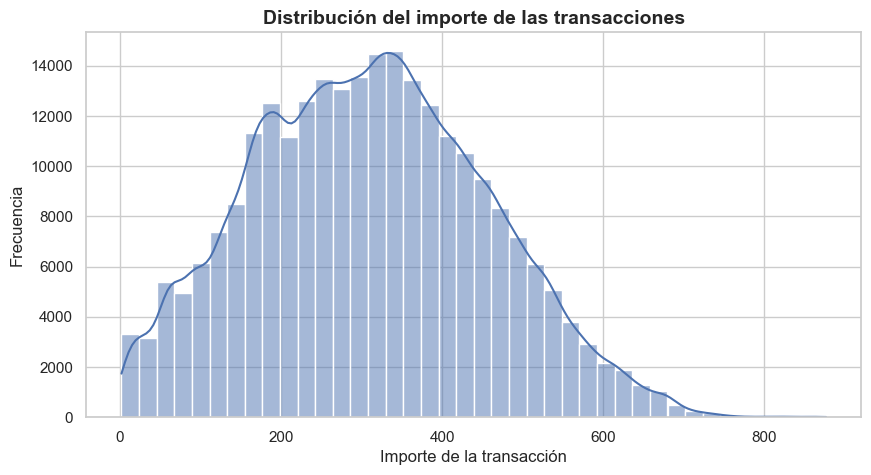

In [26]:
if check_columns(df_analysis, ["amount"]):
    plt.figure(figsize=(10, 5))
    sns.histplot(data=df_analysis, x="amount", bins=40, kde=True)

    plt.title(
        "Distribución del importe de las transacciones",
        fontsize=14,
        fontweight="bold"
    )
    plt.xlabel("Importe de la transacción")
    plt.ylabel("Frecuencia")
    plt.show()

### Interpretación
El histograma muestra la distribución de los importes de las transacciones.

Se observa que la mayor parte de los registros se concentra en importes medios, aproximadamente entre 200 y 400. La frecuencia aumenta desde los importes bajos hasta la zona central de la distribución y después disminuye de forma progresiva.

También se aprecia una ligera asimetría hacia la derecha, ya que existen algunos importes más altos, aunque son menos frecuentes. A partir de valores cercanos a 600, la frecuencia baja bastante, lo que indica que las transacciones de importe muy alto son menos habituales en el dataset.

Este gráfico es útil como primer análisis de `amount`, porque permite entender cómo se distribuyen los importes antes de compararlos con otras variables, como el país de la empresa, el estado de la transacción o las características del producto.

Como `df_analysis` está a nivel de transacción-producto, una misma transacción puede aparecer más de una vez si contiene varios productos. Por eso, esta visualización debe interpretarse como una distribución de los importes dentro del DataFrame de análisis.

## 2. Dos variables numéricas: relación entre `price` y `weight`

Para analizar dos variables numéricas, utilizo un gráfico de dispersión entre `price` y `weight`.

Este gráfico permite observar si existe alguna relación visual entre el precio de los productos y su peso. En este caso, cada punto representa un producto asociado a una transacción.

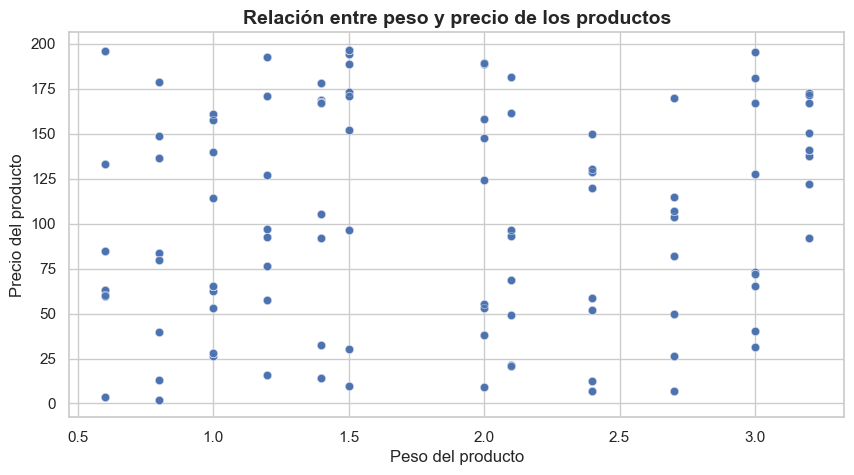

In [29]:
if check_columns(df_analysis, ["price", "weight"]):
    plt.figure(figsize=(10, 5))
    sns.scatterplot(
        data=df_analysis,
        x="weight",
        y="price",
        alpha=0.4
    )

    plt.title(
        "Relación entre peso y precio de los productos",
        fontsize=14,
        fontweight="bold"
    )
    plt.xlabel("Peso del producto")
    plt.ylabel("Precio del producto")
    plt.show()

### Interpretación
El gráfico de dispersión compara el peso y el precio de los productos.

Se observa que `weight` toma valores concretos y repetidos, aproximadamente entre 0.6 y 3.2. Esto se ve en las columnas verticales del gráfico y tiene sentido porque los datos vienen de la tabla de productos, donde cada producto tiene un peso definido.

El precio de los productos se reparte aproximadamente entre 0 y 200. Para un mismo valor de peso aparecen productos con precios bajos, medios y altos, por lo que no se aprecia una relación lineal clara entre `weight` y `price`.

Esto indica que el peso no explica por sí solo el precio del producto. Es probable que otros factores, como el tipo de producto u otras características, tengan más influencia en el precio.

Este gráfico es útil para una primera exploración de la relación entre dos variables numéricas. Permite detectar si existe una tendencia visual, posibles agrupaciones o valores atípicos antes de hacer análisis más específicos.

## 3. Una variable categórica: frecuencia de `company_country`

Para analizar una variable categórica, utilizo un gráfico de barras con la columna `company_country`.

Este gráfico permite ver cuántos registros hay asociados a cada país de empresa dentro de `df_analysis`.

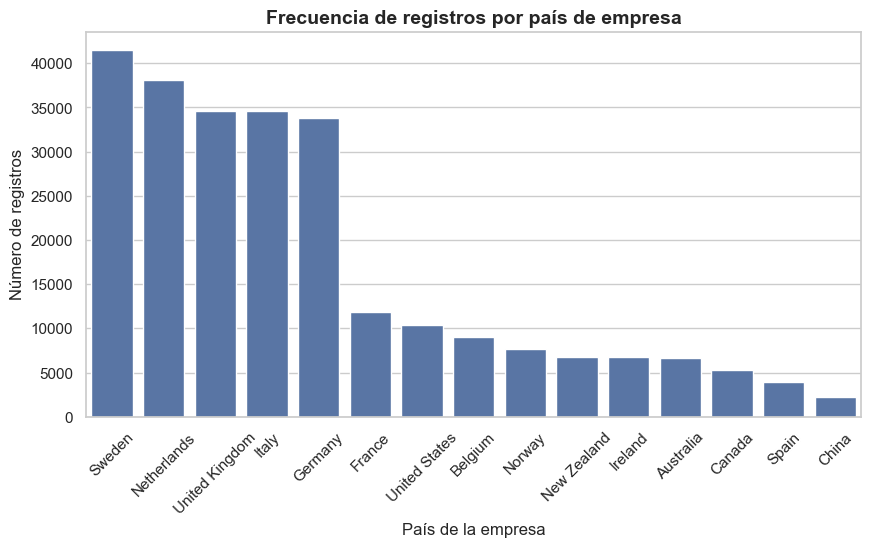

In [30]:
if check_columns(df_analysis, ["company_country"]):
    plt.figure(figsize=(10, 5))
    sns.countplot(
        data=df_analysis,
        x="company_country",
        order=df_analysis["company_country"].value_counts().index
    )

    plt.title(
        "Frecuencia de registros por país de empresa",
        fontsize=14,
        fontweight="bold"
    )
    plt.xlabel("País de la empresa")
    plt.ylabel("Número de registros")
    plt.xticks(rotation=45)
    plt.show()

### Interpretación
El gráfico muestra la frecuencia de registros según el país de la empresa.

Se observa que Suecia es el país con más registros, con algo más de 40000. Después aparecen Países Bajos, con aproximadamente 38000 registros, y Reino Unido, Italia y Alemania, con valores cercanos a 34000-35000 registros.

En cambio, países como España y China tienen una presencia mucho menor dentro del DataFrame, con valores aproximados de 4000 y 2000 registros respectivamente. Esto indica que la distribución de registros por país no es uniforme y que algunos países concentran una parte importante de la actividad registrada.

Esta visualización es útil para entender qué países tienen más peso dentro del dataset antes de realizar comparaciones con variables numéricas como `amount` o con variables categóricas como `declined`.

Como `df_analysis` está a nivel de transacción-producto, el gráfico cuenta registros asociados a productos dentro de transacciones, no únicamente transacciones únicas. Por eso, la interpretación debe hacerse teniendo en cuenta la estructura del DataFrame.

## 4. Una variable categórica y una numérica: `company_country` y `amount`

Para comparar una variable categórica con una variable numérica, utilizo un gráfico de barras con el importe medio de las transacciones por país de empresa.

En este caso, la variable categórica es `company_country` y la variable numérica es `amount`.

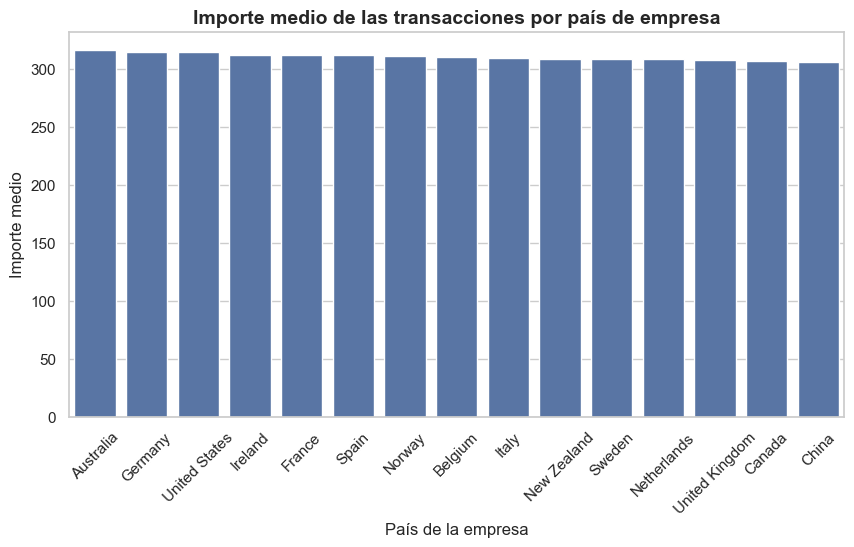

In [31]:
if check_columns(df_analysis, ["company_country", "amount"]):
    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=df_analysis,
        x="company_country",
        y="amount",
        estimator="mean",
        errorbar=None,
        order=df_analysis.groupby("company_country")["amount"].mean().sort_values(ascending=False).index
    )

    plt.title(
        "Importe medio de las transacciones por país de empresa",
        fontsize=14,
        fontweight="bold"
    )
    plt.xlabel("País de la empresa")
    plt.ylabel("Importe medio")
    plt.xticks(rotation=45)
    plt.show()

### Interpretación
El gráfico compara el importe medio de los registros según el país de la empresa.

Se observa que las diferencias entre países son pequeñas. La mayoría de países tiene un importe medio cercano a 305-315. Países como Australia, Alemania y Estados Unidos aparecen ligeramente por encima, mientras que Canadá y China muestran valores algo más bajos.

A diferencia del gráfico anterior, aquí no se analiza el volumen de registros, sino el importe medio. Esto permite ver que, aunque algunos países tienen muchos más registros que otros, el importe medio se mantiene bastante parecido entre países.

Por tanto, no se aprecia una diferencia fuerte del importe medio según el país de la empresa. Esta visualización sirve como comparación exploratoria, pero la interpretación debe hacerse con cuidado porque `df_analysis` está a nivel de transacción-producto y una misma transacción puede aparecer en varias filas si contiene varios productos.

### Análisis adicional con boxplot

Además del gráfico de barras anterior, utilizo un boxplot para comparar la distribución de `amount` según el estado de la transacción.

Este tipo de gráfico permite ver no solo la media, sino también la mediana, la dispersión y posibles valores atípicos.

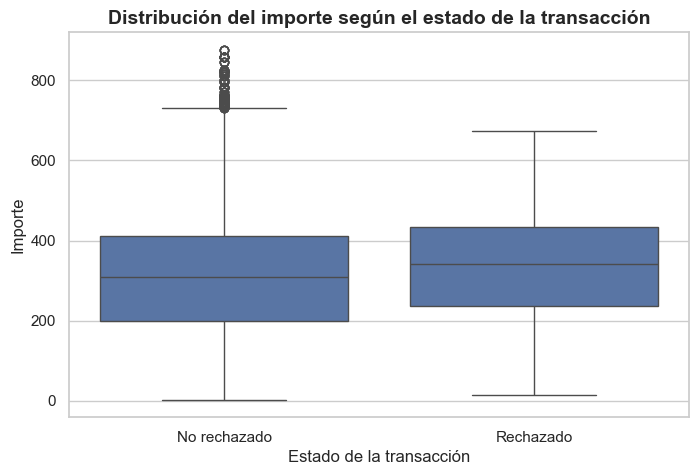

In [32]:
if check_columns(df_analysis, ["declined", "amount"]):
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=df_analysis,
        x="declined",
        y="amount"
    )

    plt.title(
        "Distribución del importe según el estado de la transacción",
        fontsize=14,
        fontweight="bold"
    )
    plt.xlabel("Estado de la transacción")
    plt.ylabel("Importe")
    plt.xticks([0, 1], ["No rechazado", "Rechazado"])
    plt.show()

### Interpretación
El boxplot compara la distribución de `amount` según el estado de la transacción.

Se observa que la mediana del importe en los registros `Rechazado` es ligeramente superior a la de `No rechazado`. También se aprecia que ambos grupos presentan una dispersión relativamente amplia, aunque la caja de `Rechazado` parece desplazada hacia importes algo más altos.

En el caso de `No rechazado`, se observan varios valores atípicos altos, con importes que superan aproximadamente los 700 y llegan cerca de 900. Esto indica que, aunque la mayor parte de los registros se concentra en valores intermedios, también existen algunos importes especialmente altos en este grupo.

Este gráfico aporta una visión más completa que un barplot, ya que no solo muestra una medida central, sino también la mediana, la dispersión y la presencia de posibles valores atípicos. Por eso, es útil como análisis complementario para entender mejor el comportamiento de `amount` según el estado de la transacción.

Aun así, la interpretación debe hacerse con cuidado. En gráficos anteriores se observó que los registros rechazados son menos numerosos que los no rechazados, por lo que la comparación entre ambos grupos puede verse afectada por esa diferencia de volumen. Además, `df_analysis` está a nivel de transacción-producto, por lo que una misma transacción puede aparecer en varias filas si contiene varios productos.

## 5. Dos variables categóricas: `company_country` y `declined`

Para analizar dos variables categóricas, utilizo un gráfico de barras agrupadas con `company_country` y `declined`.

Este gráfico permite comparar la cantidad de registros aceptados y rechazados según el país de la empresa.

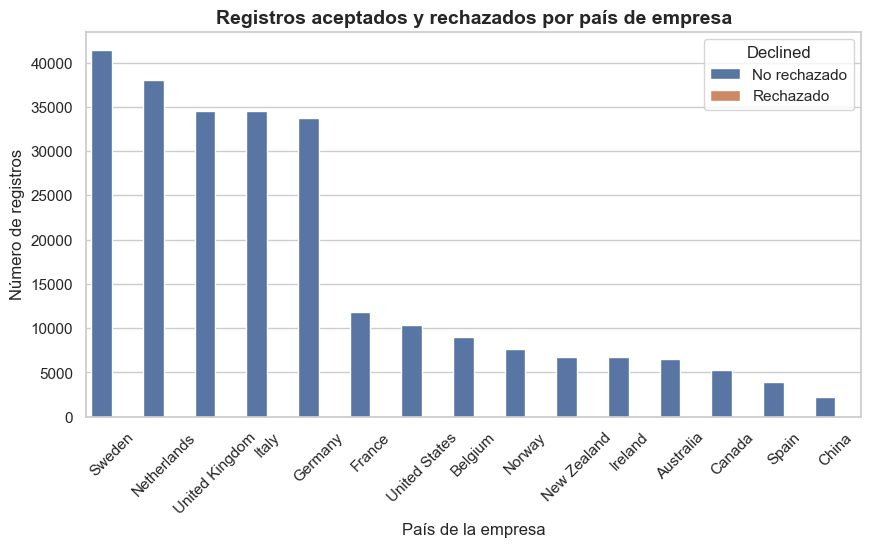

In [33]:
if check_columns(df_analysis, ["company_country", "declined"]):
    plt.figure(figsize=(10, 5))
    sns.countplot(
        data=df_analysis,
        x="company_country",
        hue="declined",
        order=df_analysis["company_country"].value_counts().index
    )

    plt.title(
        "Registros aceptados y rechazados por país de empresa",
        fontsize=14,
        fontweight="bold"
    )
    plt.xlabel("País de la empresa")
    plt.ylabel("Número de registros")
    plt.xticks(rotation=45)
    plt.legend(title="Declined", labels=["No rechazado", "Rechazado"])
    plt.show()

### Interpretación
El gráfico muestra la relación entre el país de la empresa y el estado de la transacción.

Se observa que la gran mayoría de registros corresponde a transacciones no rechazadas. Las barras de `Rechazado` son muy pequeñas en comparación con las de `No rechazado`, lo que indica que los rechazos representan una proporción baja dentro del DataFrame.

El patrón general por país es parecido al gráfico anterior: Suecia, Países Bajos, Reino Unido, Italia y Alemania concentran el mayor número de registros, mientras que España y China tienen una presencia mucho menor. Sin embargo, esta visualización muestra principalmente diferencias de volumen, no necesariamente diferencias en la tasa de rechazo.

Para comparar mejor el comportamiento de los rechazos entre países, sería necesario calcular el porcentaje de registros rechazados sobre el total de registros de cada país. Como `df_analysis` está a nivel de transacción-producto, la interpretación debe hacerse teniendo en cuenta que una misma transacción puede aparecer en varias filas si contiene varios productos.

## 6. Tres variables combinadas: `company_country`, `amount` y `declined`

Para combinar tres variables, utilizo un gráfico de barras con `company_country`, `amount` y `declined`.

En este caso comparo el importe medio de las transacciones por país de empresa, separando los resultados según si la transacción fue rechazada o no.

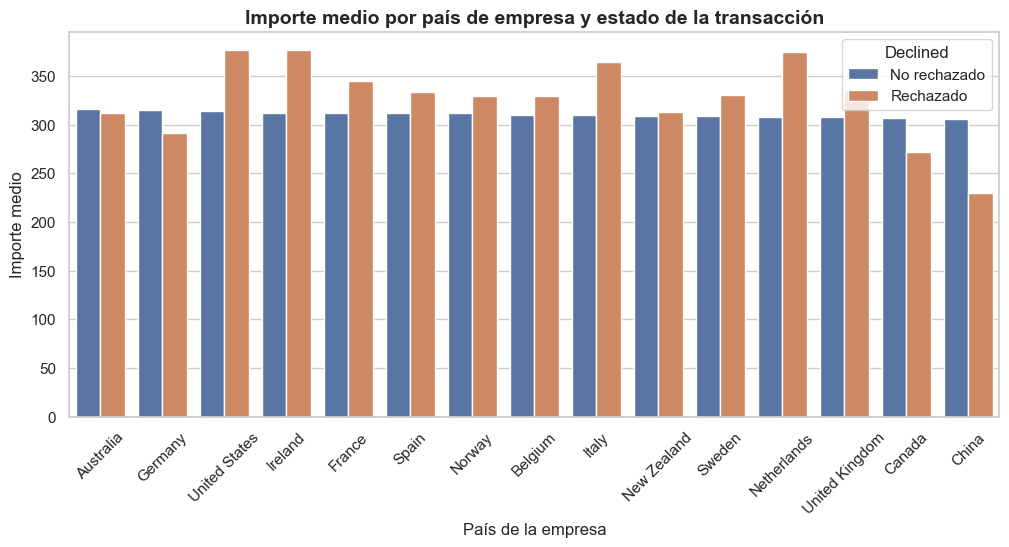

In [34]:
if check_columns(df_analysis, ["company_country", "amount", "declined"]):
    country_order = (
        df_analysis
        .groupby("company_country")["amount"]
        .mean()
        .sort_values(ascending=False)
        .index
    )

    plt.figure(figsize=(12, 5))
    sns.barplot(
        data=df_analysis,
        x="company_country",
        y="amount",
        hue="declined",
        estimator="mean",
        errorbar=None,
        order=country_order
    )

    plt.title(
        "Importe medio por país de empresa y estado de la transacción",
        fontsize=14,
        fontweight="bold"
    )
    plt.xlabel("País de la empresa")
    plt.ylabel("Importe medio")
    plt.xticks(rotation=45)
    plt.legend(title="Declined", labels=["No rechazado", "Rechazado"])
    plt.show()

### Interpretación
El gráfico compara el importe medio por país de empresa y por estado de la transacción.

Se observa que los registros `No rechazado` tienen importes medios bastante parecidos entre países, aproximadamente entre 305 y 315. Esto indica que, para las transacciones no rechazadas, el país de la empresa no parece generar grandes diferencias en el importe medio.

En cambio, los registros `Rechazado` muestran más variación entre países. En países como Estados Unidos, Irlanda y Países Bajos, el importe medio de los registros rechazados es más alto, con valores cercanos a 370-380. En otros países, como Canadá o China, el importe medio de los registros rechazados es más bajo.

Esta visualización permite ver una diferencia que no aparecía tan claramente en el gráfico anterior: al separar los registros por estado de la transacción, se observan variaciones más marcadas en algunos países.

Aun así, la interpretación debe hacerse con cuidado. En el gráfico anterior se observó que los registros rechazados son muchos menos que los no rechazados, por lo que algunas medias de `Rechazado` pueden estar calculadas sobre un número reducido de registros. Además, `df_analysis` está a nivel de transacción-producto, por lo que una misma transacción puede aparecer en varias filas si contiene varios productos.

## 7. Pairplot

Para cerrar el Nivel 1, creo un `pairplot` con varias variables numéricas.

Este gráfico permite observar varias relaciones entre variables al mismo tiempo. En este caso utilizo `amount`, `price`, `weight`, `lat` y `longitude`. Como el DataFrame tiene muchas filas, primero tomo una muestra para que el gráfico sea más rápido y legible.

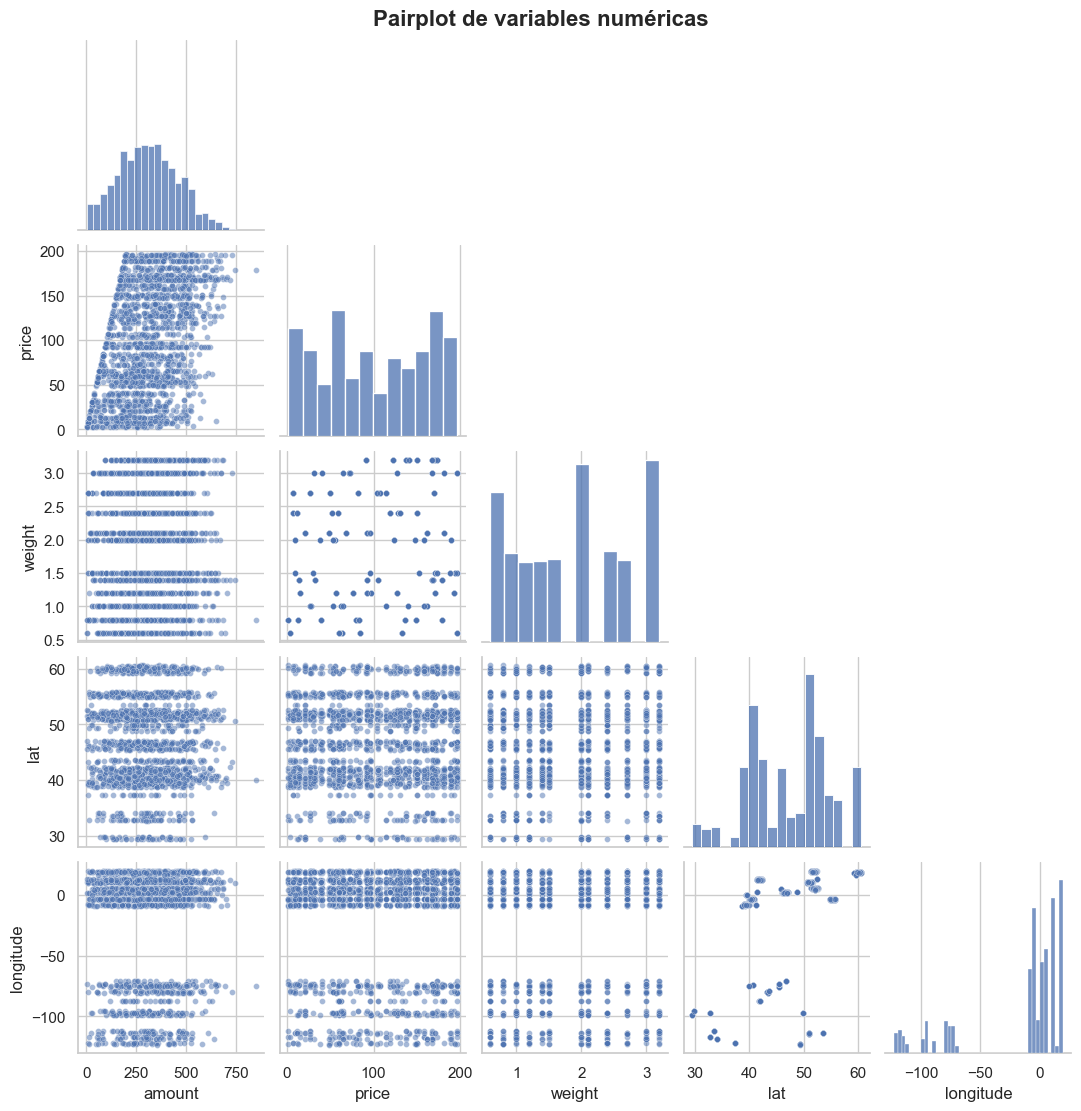

In [38]:
if check_columns(df_analysis, ["amount", "price", "weight", "lat", "longitude"]):
    pairplot_columns = ["amount", "price", "weight", "lat", "longitude"]
    
    df_pairplot = (
        df_analysis[pairplot_columns]
        .dropna()
        .sample(n=2000, random_state=42)
    )

    pair_grid = sns.pairplot(
        df_pairplot,
        diag_kind="hist",
        corner=True,
        height=2.2,
        plot_kws={"alpha": 0.5, "s": 18}
    )

    pair_grid.fig.suptitle(
        "Pairplot de variables numéricas",
        y=1.01,
        fontsize=16,
        fontweight="bold"
    )

    plt.show()

### Interpretación
El pairplot permite observar de forma conjunta varias relaciones entre variables numéricas.

En este caso, se comparan `amount`, `price`, `weight`, `lat` y `longitude`. En la diagonal se observa la distribución individual de cada variable, mientras que en la parte inferior del gráfico se muestran las relaciones entre pares de variables. Se utiliza `corner=True` para evitar repetir la misma relación dos veces y hacer la visualización más clara.

Se observa que `amount` se concentra sobre todo en valores medios, aproximadamente entre 200 y 400. También se confirma que no hay una relación lineal clara entre `price` y `weight`, ya que los productos con más peso no necesariamente tienen un precio más alto.

La variable `weight` muestra valores concretos y repetidos, lo que genera líneas o agrupaciones visibles en algunos gráficos. Esto tiene sentido porque los datos vienen de la tabla de productos, donde cada producto tiene un peso definido.

También se observan concentraciones en las variables geográficas `lat` y `longitude`, lo que indica que los registros no están distribuidos de forma completamente uniforme en el espacio geográfico.

En general, este gráfico funciona como una exploración inicial. No confirma relaciones causales, pero ayuda a detectar patrones visuales, posibles agrupaciones y relaciones que podrían analizarse después con métodos más específicos.

Para que la visualización sea más clara y el notebook se ejecute mejor, se ha utilizado una muestra de 2000 registros.

# Nivel 2 - Correlación y Jointplot

En este nivel analizo la relación entre algunas variables numéricas del DataFrame.

Primero calculo una matriz de correlación para ver si algunas variables se mueven juntas de forma positiva o negativa. Después utilizo un `jointplot` para explorar con más detalle la relación entre dos variables concretas.

## 1. Correlación entre variables numéricas

Para representar la correlación, selecciono algunas variables numéricas de `df_analysis`: `amount`, `price`, `weight`, `lat`, `longitude`, `year`, `month`, `hour` y `declined`.

La matriz de correlación permite ver si dos variables tienen una relación positiva, negativa o muy débil. Para visualizarla de forma más clara, utilizo un mapa de calor.

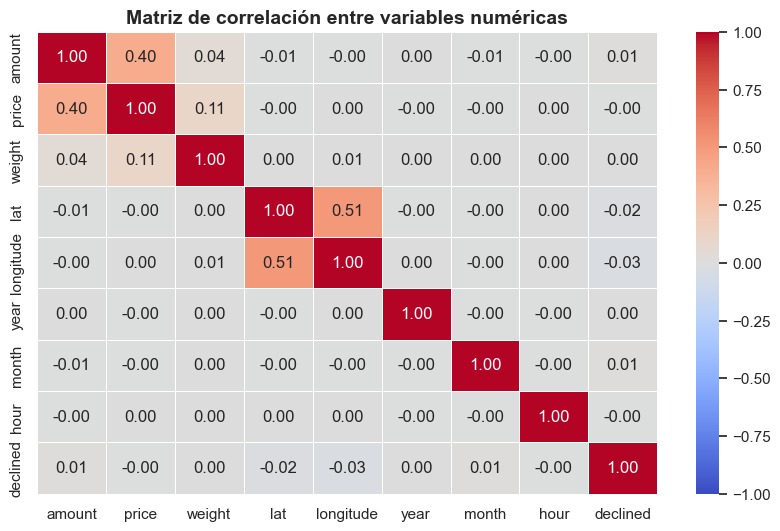

In [39]:
if check_columns(df_analysis, ["amount", "price", "weight", "lat", "longitude", "year", "month", "hour", "declined"]):
    correlation_columns = [
        "amount",
        "price",
        "weight",
        "lat",
        "longitude",
        "year",
        "month",
        "hour",
        "declined"
    ]

    correlation_matrix = df_analysis[correlation_columns].corr()

    plt.figure(figsize=(10, 6))
    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        linewidths=0.5
    )

    plt.title(
        "Matriz de correlación entre variables numéricas",
        fontsize=14,
        fontweight="bold"
    )
    plt.show()

### Interpretación

La matriz de correlación muestra la relación lineal entre varias variables numéricas de `df_analysis`. En este gráfico, la escala de color se ha fijado entre -1 y 1, porque la correlación puede tomar valores desde una relación negativa fuerte hasta una relación positiva fuerte.

En general, la mayoría de correlaciones son bajas y están cerca de 0. Esto indica que no se observa una relación lineal fuerte entre la mayoría de variables analizadas.

La relación más destacada aparece entre `lat` y `longitude`, con una correlación aproximada de 0.51. Esto sugiere que las variables geográficas presentan cierta relación entre sí, probablemente porque los registros se concentran en determinadas zonas geográficas.

También se observa una correlación positiva moderada entre `amount` y `price`, con un valor aproximado de 0.40. Esto indica que, en algunos casos, los productos con precios más altos pueden estar asociados a importes de transacción más altos. Aun así, la relación no es muy fuerte, porque `amount` representa el importe de la transacción y una misma transacción puede incluir varios productos.

La correlación entre `price` y `weight` es baja, aproximadamente 0.11. Esto confirma lo observado en el scatter plot: el peso del producto no explica de forma clara su precio.

Por otro lado, `declined` presenta correlaciones muy cercanas a 0 con el resto de variables. Esto indica que, en este análisis, el estado de la transacción no muestra una relación lineal clara con variables como `amount`, `price`, `weight` o las variables temporales.

En resumen, esta matriz sirve como una revisión general para detectar relaciones numéricas. Aunque no se observan correlaciones fuertes, sí permite identificar algunas relaciones moderadas, como `amount` con `price` y `lat` con `longitude`, que podrían explorarse con más detalle si fuera necesario.

## 2. Jointplot entre `price` y `weight`

Para explorar con más detalle la relación entre dos variables numéricas, utilizo un `jointplot` con `price` y `weight`.

Este gráfico combina un gráfico de dispersión con las distribuciones individuales de cada variable. Así puedo ver al mismo tiempo la relación entre precio y peso, y cómo se distribuye cada variable por separado.

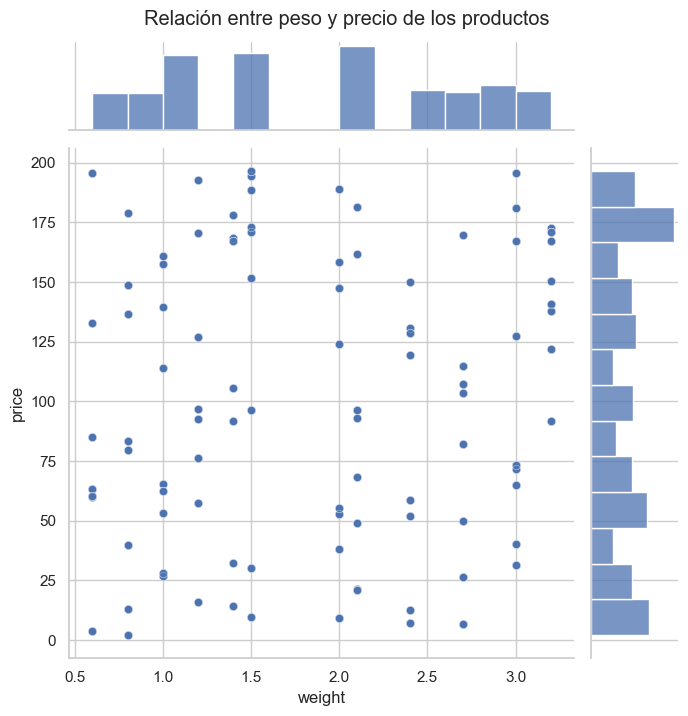

In [24]:
if check_columns(df_analysis, ["price", "weight"]):
    df_jointplot = (
        df_analysis[["price", "weight"]]
        .dropna()
        .sample(n=3000, random_state=42)
    )

    sns.jointplot(
        data=df_jointplot,
        x="weight",
        y="price",
        kind="scatter",
        height=7,
        alpha=0.4
    )

    plt.suptitle("Relación entre peso y precio de los productos", y=1.02)
    plt.show()

### Interpretación

El jointplot permite analizar la relación entre `weight` y `price` y, al mismo tiempo, observar la distribución individual de cada variable.

En el gráfico central se muestra la relación entre el peso y el precio de los productos. No se observa una relación lineal clara entre ambas variables, ya que los puntos no siguen una tendencia ascendente o descendente definida. Para un mismo valor de peso aparecen productos con precios bajos, medios y altos.

La distribución superior muestra que `weight` toma valores concretos y repetidos, aproximadamente entre 0.6 y 3.2. Esto tiene sentido porque los datos vienen de la tabla de productos, donde cada producto tiene un peso definido.

La distribución lateral muestra que `price` se reparte aproximadamente entre 0 y 200, con valores distribuidos en diferentes rangos. Esto indica que el precio no depende únicamente del peso del producto.

En general, este gráfico confirma lo observado en el scatter plot anterior: el peso no explica por sí solo el precio. Además, el jointplot aporta una lectura más completa porque combina la relación entre dos variables con la distribución individual de cada una.

Para que la visualización sea más clara y el notebook se ejecute mejor, se ha utilizado una muestra de registros.

# Nivel 3 - Integración con Power BI mediante scripts de Python

En este nivel traslado las visualizaciones del Nivel 1 a Power BI utilizando scripts de Python.

Para ello, se utiliza el DataFrame `df_analysis`, que ya contiene la información necesaria para las visualizaciones: transacciones, productos, empresas, usuarios, estado de la tarjeta y datos temporales y geográficos.

También se mantiene la columna `row_id` como identificador único de cada fila. Esto es importante porque Power BI puede eliminar registros duplicados si no hay una columna que garantice la unicidad de cada registro.

## Procedimiento seguido en Power BI

1. Se conecta Power BI a la base de datos `sprint4_star` de MySQL.
2. Se carga la consulta SQL utilizada para crear `df_analysis`.
3. Se mantiene la columna `row_id` como identificador único de cada fila.
4. Para cada visualización del Nivel 1, se crea un objeto visual de Python.
5. En cada visualización se añaden las columnas necesarias al apartado de valores.
6. En el editor de Python de Power BI se utiliza un script equivalente al del notebook, usando `dataset` como DataFrame de entrada.

## Nota sobre los scripts en Power BI

Los scripts de Python utilizados en Power BI no se ejecutan dentro de este notebook. Se han implementado directamente en el archivo `.pbix`.

La principal diferencia es que en Jupyter se trabaja con `df_analysis`, mientras que en Power BI el DataFrame disponible dentro de cada visual de Python se llama `dataset`.

| Visualización | Columnas utilizadas en Power BI | Tipo de gráfico |
|---|---|---|
| Distribución de `amount` | `row_id`, `amount` | Histograma |
| Relación entre `weight` y `price` | `row_id`, `weight`, `price` | Scatter plot |
| Frecuencia por `company_country` | `row_id`, `company_country` | Countplot |
| Importe medio por `company_country` | `row_id`, `company_country`, `amount` | Barplot |
| Distribución de `amount` según `declined` | `row_id`, `declined`, `amount` | Boxplot adicional |
| Estado de transacción por país | `row_id`, `company_country`, `declined` | Countplot agrupado |
| Importe medio por país y estado | `row_id`, `company_country`, `amount`, `declined` | Barplot agrupado |
| Pairplot de variables numéricas | `row_id`, `amount`, `price`, `weight`, `lat`, `longitude` | Pairplot |

## Resultado del Nivel 3

Las visualizaciones del Nivel 1 se han incorporado en Power BI mediante scripts de Python.

El archivo `.pbix` contiene las visualizaciones solicitadas y se entrega junto con este notebook en la carpeta del repositorio de GitHub.

# Conclusiones finales

En esta práctica se ha trabajado todo el proceso de visualización de datos a partir de la base de datos `sprint4_star`.

Primero se ha conectado Python con MySQL y se han cargado todas las tablas de forma automática. Después se ha creado un DataFrame principal de análisis, `df_analysis`, combinando información de transacciones, productos, empresas, usuarios, estado de la tarjeta y datos temporales y geográficos.

Las visualizaciones del Nivel 1 han permitido analizar diferentes tipos de variables: numéricas, categóricas y combinadas. En general, se observa que no hay relaciones lineales muy fuertes entre la mayoría de variables numéricas, aunque aparecen algunas relaciones moderadas, como `amount` con `price` y `lat` con `longitude`.

También se ha comprobado que `transaction_id` no es único dentro de `df_analysis`, porque una misma transacción puede incluir varios productos. Por este motivo, la columna `row_id` se utiliza como identificador único, especialmente para trabajar correctamente en Power BI.

Finalmente, las visualizaciones se trasladan a Power BI mediante scripts de Python, manteniendo la misma lógica de análisis utilizada en el notebook.